In [4]:
# 환경에 대한 정보값을 보고자 할 때
import os # operating system
# os라는 모듈은 객체이다
# 나는 어디에서 작업하고 있니?
print(os.getcwd()) # current working directory
# 폴더 안에 뭐가 있니?
print(os.listdir()) # list directory

C:\Users\user\mktdata_260707
['.ipynb_checkpoints', '260716_01.ipynb', 'ga4_product_funnel_01.csv', 'marketing_project.ipynb']


In [5]:
# pandas 
# 1) 라이브러리 모듈 내부에 있는 속성과 메서드(함수, 연장) 기능 방대
# 2) 파이썬 언어를 기반으로 시각화를 도와주는 기타 모듈과의 호환성 끝판왕 (matplotlib, ploty, seaborn)
# 3) 저장해놓은 자료 (데이터 프레임) -> M/L(머신러닝) 호환성이 너무 좋음
# 4) 외부 기타 로우데이터와의 호환성 (plain text, csv, exel, sql)

In [7]:
!pip install pandas

In [1]:
import pandas as pd
funnel_df = pd.read_csv('ga4_product_funnel_01.csv')

In [2]:
funnel_df.head(5)

,item_name,view_users,cart_users,checkout_users,purchase_users,item_revenue,view_to_cart_pct,cart_to_checkout_pct,checkout_to_purchase_pct,view_to_purchase_pct
0,Super G Unisex Joggers,14713,3471,240,221,9529.0,23.59,6.91,92.08,1.50
1,Google Zip Hoodie F/C,13869,3539,218,218,13788.0,25.52,6.16,100.00,1.57
2,Google Navy Speckled Tee,13696,3527,120,129,4440.0,25.75,3.40,107.50,0.94
3,YouTube Icon Tee Grey,12696,2122,58,58,1356.0,16.71,2.73,100.00,0.46
4,Google Campus Bike Eco Tee Navy,11339,3063,33,41,1165.0,27.01,1.08,124.24,0.36


In [14]:
# 몇 행 몇 열이냐?
funnel_df.shape

(413, 10)

In [16]:
# 데이터명세?서?
funnel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   item_name                 413 non-null    object 
 1   view_users                413 non-null    int64  
 2   cart_users                413 non-null    int64  
 3   checkout_users            413 non-null    int64  
 4   purchase_users            413 non-null    int64  
 5   item_revenue              413 non-null    float64
 6   view_to_cart_pct          413 non-null    float64
 7   cart_to_checkout_pct      406 non-null    float64
 8   checkout_to_purchase_pct  379 non-null    float64
 9   view_to_purchase_pct      413 non-null    float64
dtypes: float64(5), int64(4), object(1)
memory usage: 32.4+ KB


In [17]:
# null값 카운트
funnel_df.isnull().sum()

item_name                    0
view_users                   0
cart_users                   0
checkout_users               0
purchase_users               0
item_revenue                 0
view_to_cart_pct             0
cart_to_checkout_pct         7
checkout_to_purchase_pct    34
view_to_purchase_pct         0
dtype: int64

In [22]:
# 전체 데이터 중 null의 평균값
# 비율이 높으면 살리는 등 결정 가능
funnel_df.isnull().mean().mul(100).round(2) # 메서드를 연타로 연결하는 것을 method chaining이라고 함
# null의 전체의 평균 곱하기100을 해서 %로 변환 소수점 2자리까지 남김

item_name                   0.00
view_users                  0.00
cart_users                  0.00
checkout_users              0.00
purchase_users              0.00
item_revenue                0.00
view_to_cart_pct            0.00
cart_to_checkout_pct        1.69
checkout_to_purchase_pct    8.23
view_to_purchase_pct        0.00
dtype: float64

In [3]:
# 서브 블라블라 결측이 발견된다면 드랍시켜(버려)
funnel_df = funnel_df.dropna(subset=["cart_to_checkout_pct"]).reset_index(drop=True) # drop'na' = not available

In [4]:
# 괄호에 넣으면 열 정리 가능
funnel_df = (
    funnel_df
        .dropna(
            subset=["checkout_to_purchase_pct"]
        ).reset_index(drop=True)
)

In [5]:
funnel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   item_name                 379 non-null    object 
 1   view_users                379 non-null    int64  
 2   cart_users                379 non-null    int64  
 3   checkout_users            379 non-null    int64  
 4   purchase_users            379 non-null    int64  
 5   item_revenue              379 non-null    float64
 6   view_to_cart_pct          379 non-null    float64
 7   cart_to_checkout_pct      379 non-null    float64
 8   checkout_to_purchase_pct  379 non-null    float64
 9   view_to_purchase_pct      379 non-null    float64
dtypes: float64(5), int64(4), object(1)
memory usage: 29.7+ KB


In [30]:
funnel_df

,item_name,view_users,cart_users,checkout_users,purchase_users,item_revenue,view_to_cart_pct,cart_to_checkout_pct,checkout_to_purchase_pct,view_to_purchase_pct
0,Super G Unisex Joggers,14713,3471,240,221,9529.0,23.59,6.91,92.08,1.50
1,Google Zip Hoodie F/C,13869,3539,218,218,13788.0,25.52,6.16,100.00,1.57
2,Google Navy Speckled Tee,13696,3527,120,129,4440.0,25.75,3.40,107.50,0.94
3,YouTube Icon Tee Grey,12696,2122,58,58,1356.0,16.71,2.73,100.00,0.46
4,Google Campus Bike Eco Tee Navy,11339,3063,33,41,1165.0,27.01,1.08,124.24,0.36
...,...,...,...,...,...,...,...,...,...,...
374,Google PNW Campus Ladies Tee,52,20,5,6,92.0,38.46,25.00,120.00,11.54
375,Gift Card - $25.00,35,11,7,6,1125.0,31.43,63.64,85.71,17.14
376,Google Boulder Campus Tote,35,14,7,6,36.0,40.00,50.00,85.71,17.14
377,Android Cardboard Sculpture,33,5,1,0,0.0,15.15,20.00,0.00,0.00


In [6]:
funnel_df["cart_purchase_gap"] = (
    funnel_df["cart_users"] - funnel_df["purchase_users"]
)

In [7]:
funnel_df.head()

,item_name,view_users,cart_users,checkout_users,purchase_users,item_revenue,view_to_cart_pct,cart_to_checkout_pct,checkout_to_purchase_pct,view_to_purchase_pct,cart_purchase_gap
0,Super G Unisex Joggers,14713,3471,240,221,9529.0,23.59,6.91,92.08,1.50,3250
1,Google Zip Hoodie F/C,13869,3539,218,218,13788.0,25.52,6.16,100.00,1.57,3321
2,Google Navy Speckled Tee,13696,3527,120,129,4440.0,25.75,3.40,107.50,0.94,3398
3,YouTube Icon Tee Grey,12696,2122,58,58,1356.0,16.71,2.73,100.00,0.46,2064
4,Google Campus Bike Eco Tee Navy,11339,3063,33,41,1165.0,27.01,1.08,124.24,0.36,3022


In [8]:
# 원본 데이터 프레임 가급적 건드리지 않고, 필터링된 데이터들을 모아놓은 데이터 프레임 활용 예정

problem_products = (
    funnel_df[(funnel_df["view_users"] >= 50) & (funnel_df["cart_users"] >= 10)
        ].sort_values(
            "cart_purchase_gap", 
            ascending=False # 판다스는 오름차순밖에 없어서 쓸거냐 안쓸거냐를 결정
        ).head(15)
)

In [9]:
problem_products.head()

,item_name,view_users,cart_users,checkout_users,purchase_users,item_revenue,view_to_cart_pct,cart_to_checkout_pct,checkout_to_purchase_pct,view_to_purchase_pct,cart_purchase_gap
5,Google Land & Sea Cotton Cap,10796,3569,126,104,2425.0,33.06,3.53,82.54,0.96,3465
2,Google Navy Speckled Tee,13696,3527,120,129,4440.0,25.75,3.40,107.50,0.94,3398
1,Google Zip Hoodie F/C,13869,3539,218,218,13788.0,25.52,6.16,100.00,1.57,3321
0,Super G Unisex Joggers,14713,3471,240,221,9529.0,23.59,6.91,92.08,1.50,3250
7,YouTube Leather Strap Hat Black,10543,3198,83,67,1065.0,30.33,2.60,80.72,0.64,3131


In [36]:
!pip install plotly

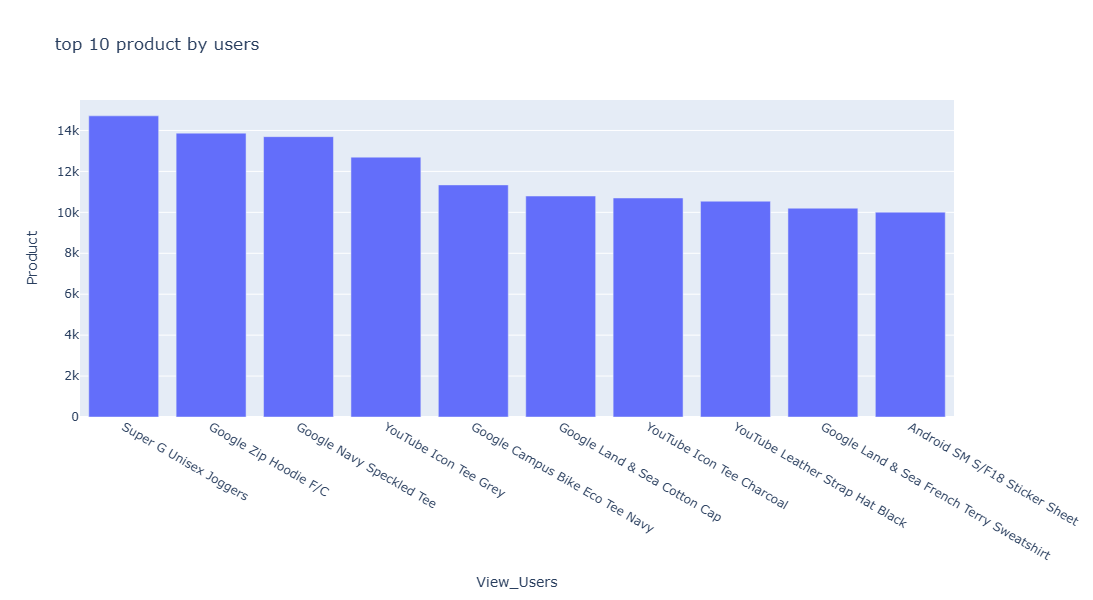

In [10]:
import plotly.express as px

top_view_products = (
    funnel_df
    .nlargest(10, "view_users") # n은 갯수를 말함, 유저 상품조회 10위까지
    .sort_values("view_users", ascending=False)
)

fig = px.bar(
    top_view_products,
    x="item_name",
    y="view_users",
    # 제목을 넣쟈
    title = "top 10 product by users"
)

fig.update_layout(
    # axis 축
    xaxis_title = "View_Users",
    yaxis_title = "Product",
    height = 600
)

fig.show()

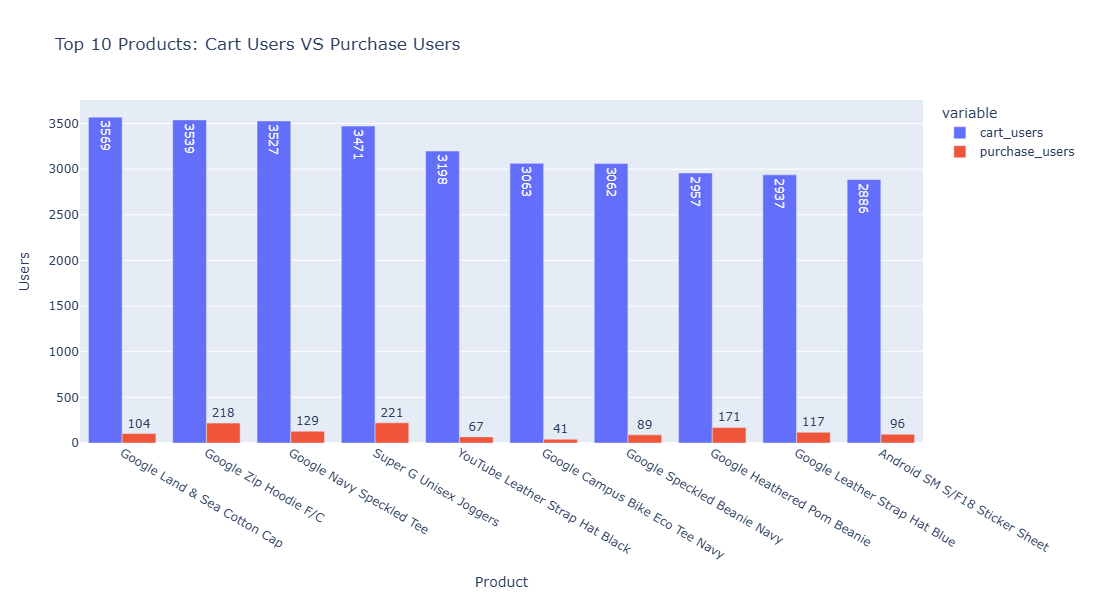

In [57]:
import plotly.express as px

# 장바구니로 이동시킨 수 기준 vs 상품결제 수 비교!

cart_purchase_df = (
    funnel_df
    .nlargest(10, "cart_users")
    .sort_values(
        "cart_users",
        ascending=False
    )
)

fig = px.bar(
    cart_purchase_df,
    x="item_name",
    y=["cart_users", "purchase_users"], # 콤보차트
    barmode="group",
    title="Top 10 Products: Cart Users VS Purchase Users",
    labels={
        "item_name": "Product",
        "value": "Users",
        "variabl": "Funnel Stage"
    },
    text_auto=True
)

fig.update_layout(
    height=600
)

fig.show()

In [47]:
top_view_products

,item_name,view_users,cart_users,checkout_users,purchase_users,item_revenue,view_to_cart_pct,cart_to_checkout_pct,checkout_to_purchase_pct,view_to_purchase_pct,cart_purchase_gap
0,Super G Unisex Joggers,14713,3471,240,221,9529.0,23.59,6.91,92.08,1.50,3250
1,Google Zip Hoodie F/C,13869,3539,218,218,13788.0,25.52,6.16,100.00,1.57,3321
2,Google Navy Speckled Tee,13696,3527,120,129,4440.0,25.75,3.40,107.50,0.94,3398
3,YouTube Icon Tee Grey,12696,2122,58,58,1356.0,16.71,2.73,100.00,0.46,2064
4,Google Campus Bike Eco Tee Navy,11339,3063,33,41,1165.0,27.01,1.08,124.24,0.36,3022
5,Google Land & Sea Cotton Cap,10796,3569,126,104,2425.0,33.06,3.53,82.54,0.96,3465
6,YouTube Icon Tee Charcoal,10700,1998,99,83,1805.0,18.67,4.95,83.84,0.78,1915
7,YouTube Leather Strap Hat Black,10543,3198,83,67,1065.0,30.33,2.60,80.72,0.64,3131
8,Google Land & Sea French Terry Sweatshirt,10201,1904,47,28,1375.0,18.66,2.47,59.57,0.27,1876
9,Android SM S/F18 Sticker Sheet,10007,2886,111,96,342.0,28.84,3.85,86.49,0.96,2790


In [ ]:
# webdriver : 크롤러의 역할 (나를 대신해서 크롤링을 해오는 역할 = 스파이더)
# ChromeDriverManager > Service > service : 우리 브라우저인 것처럼 행동 (로컬 컴퓨터의 브라우저 버전 이식)
# Options : 실제 브라우저 습관 가지고 움직

In [22]:
!pip install selenium

  Using cached trio-0.33.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached trio_websocket-0.12.2-py3-none-any.whl.metadata (5.1 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached outcome-1.3.0.post0-py2.py3-none-any.whl.metadata (2.6 kB)
  Using cached wsproto-1.3.2-py3-none-any.whl.metadata (5.2 kB)
   ---------------------------------------- 0.0/9.4 MB ? eta -:--:--
   ---------------------------------------- 9.4/9.4 MB 75.1 MB/s  0:00:00
Using cached trio-0.33.0-py3-none-any.whl (510 kB)
Using cached trio_websocket-0.12.2-py3-none-any.whl (21 kB)
Using cached urllib3-2.7.0-py3-none-any.whl (131 kB)
Using cached outcome-1.3.0.post0-py2.py3-none-any.whl (10 kB)
Using cached wsproto-1.3.2-py3-none-any.whl (24 kB)

  Attempting uninstall: urllib3

    Found existing installation: urllib3 2.5.0

    Uninstalling urllib3-2.5.0:

      Successfully uninstalled urllib3-2.5.0

   ------ --------------------------------- 1/6 [urllib3]
   -------------------- 

In [14]:
# 설치된 브라우저의 버전을 맞출 수 있게 도와주는 모듈
!pip install webdriver_manager

In [1]:
# 문자값으로 받을거야, 문자값으로 반환할거야
# 브라우저와 드라이버를 일치시켜줘야 발각이 안됨
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from webdriver_manager.chrome import ChromeDriverManager

service = Service(ChromeDriverManager().install())
options = Options()

def get_rendered_html_selenium(url: str) -> str :
    # options.add_argument("--headless=new")
    # options.add_argument("--disable-gpu")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--window-size=1920,1080")
    options.add_argument("--start-maximized")
    options.add_argument("--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36")
    options.add_argument("--lang=ko_KR")
    options.add_argument("--no-sandbox")
    
    driver= webdriver.Chrome(service=service, options=options)

    try :
        driver.get(url)

        WebDriverWait(
            driver,
            30
        ).until(
            lambda browser :
            "schema.org/Product"
            in browser.page_source
        )

        return driver.page_source
        
    finally :
        driver.quit()

# 크롤링 코드 한 방에 길게 작상 위험
# 길게 작성된 코드에 문제(너느지점 왜?) > Debugginf
# 기능별 주요 행심 기능을 파셜(부분화해서 함수)
# 최종 크롤링은 붑ㄴ화되어 있는 함수들을 순차적으로 실행
# Refactorying 기법

In [2]:
from bs4 import BeautifulSoup
SHOP_URL="https://shop.merch.google/shop/new"
html = get_rendered_html_selenium (SHOP_URL)
soup = BeautifulSoup (html, "html.parser")
cards= soup.select('[itemtype*="schema.org/Product"]')
print(len(cards))

16


In [3]:
from bs4 import BeautifulSoup

SHOP_URL = "https://shop.merch.google/shop/new"

html = get_rendered_html_selenium(SHOP_URL)

soup = BeautifulSoup(html, "html.parser")

cards = soup.select('[itemtype*="schema.org/Product"]')

print(len(cards))

16


In [ ]:
# spa 동적사이트, request, bs4 크롤링 불가
# selenium 라이브러리 모듈 활용

In [ ]:
# lambda 식 : 간단한 함수식
# 함수와 같이 어떤 기능을 가지고 있는 식을 만들고자 할 때
# 익명함수

def func(a):
    return a + 10 # 함수 구'문' (문장 = 2줄 이상 작성, 선언식, 실행문)
    
    # 어떤 함수를 또 다른 함수 내부에 매개변수로 가져다가 선언 불가
    # 프로그래밍 언어 : 함수 1급 시민 = 특별시민

In [13]:
import re # regular expression = 정규표현식
import pandas as pd
# urllib 라이브러리
from urllib.parse import urljoin

# 절대경로 상수값으로 저장
CATEGORY_URL = "https://shop.merch.google"

products = list()

for card in cards :
    image = card.select_one('img[itemprop="image"]')
    link = card.select_one('a[itemprop="url"][href]')

    product_name = (
        image.get("alt")
        if image
        else None
        # 삼항조건인데 사망조건인 줄..
    )
    card_text = card.get_text(" ", strip=True)
    price_match = re.search(
        r"\$\s*[\d]+(?:\.\d{2})?",# $ 뒤에 s공백이 *있을 수 있고 없을 수 있다, \d 정수
         card_text
    )

    price_text = (
        price_match.group()
        if price_match
        else None
    )

    product_url = (
        # url join으로 절대경로와 상대경로를 합쳐준다
        urljoin(
            CATEGORY_URL,
            link.get("href")
        )
        if link
        else None
    )

    products.append({
        "product_name": product_name,
        "price_text": price_text,
        "product_url": product_url
    })

catalog_df = pd.DataFrame(products)
    

    ## 개발 : git & git-hub : 지옥에서 온 깃
    ## 개발 : 정규표현식 -> 데이터 필수 (생성형 AI)
    # re : 정규표현식 객체
    # searcg : 정규표현식 객체가 사용할 수 있는 매서드 중 하나 => 특정 문자열에서 정규표현식에 매칭되는 값을 서칭해서 찾아와라
    # r : raw string = 정규표현식 문에서 일반문자 처럼 생겼지만, 정규표현식 안에서 고유한 기능을 수행하는 문자열 존재
    # 해당 특수문자열의 경우, 순수하게(raw) 문자열 그대로 사용하도록 하기 위한 사전 장치
    # \$ : $ 는 자체의 의미를 가지고 있기 때문에, 순수한 $문자로서의 역할을 적용하기 위해서 앞에 \ 붙임(있는 그대로의 문자열)
    # \s : space = 정규표현식에서 공간 여백을 뜻함
    # * : 0개(번) 이상 $45 $79 $    9]
    # [\d] : 문자집합을 찾아오려고 할때, \d = decimal
    # + : 1개 이상  $3 $76
    # $ 34
    # (): 그룹으로서 문자열 값을 찾아올 때 -> 그룹으로서 값을 찾아오게 되면 찾아온 해당 값을 별도의 그룹 공간에다가 저장
    # 뒤에 소수점을 기준으로 한 값만 따로 저장 된다는 이야기(알앗거 자동으로)
    # (?:\.\d{2})? : ~으로 끝난다
    # ^\$ : 문자열의 시작이 무조건 $
    # [^\$] : $빼고 모든 문자열 허용    

In [5]:
card # 태그 안에 조재하는 텍스트 > 상품가격

<div class="item" itemprop="itemListElement" itemscope="" itemtype="https://schema.org/Product" style="height:100%"><div class="carreaux_presentation_light" style="height:100%;padding-bottom:3px"><div class="leaveHoverEffect"><div class=""><a aria-label="View Google Brant Point Pullover" class="image-link" href="/product/google-brant-point-pullover-ggoegxxx2647?itemListName=Category" itemprop="url" style="background-position:center;background-size:cover;width:100%" tabindex="-1"><img alt="Google Brant Point Pullover" blurdataurl="https://ik.imagekit.io/RM/tr:h-200,dpr-2,f-auto,q-75/store/20160512512/assets/items/largeimages/GGOEGXXX2647.jpg?nid=7130" height="217" itemprop="image" layout="responsive" loading="lazy" placeholder="blur" quality="75" src="https://ik.imagekit.io/RM/tr:h-200,dpr-2,f-auto,q-75/store/20160512512/assets/items/largeimages/GGOEGXXX2647.jpg?nid=7130" width="217"/></a></div><div style="display:flex;flex-direction:column;flex-grow:1"><a class="item-detail" href="/pro

1. Marketing - ATL / BTL
2. Marketing Process - NSM / ORK / KPI...
3. GA4(웹 사이트 유입 트래픽 데이터)
4. BigQuery (SQL)
5. Python, Crawling, SQL, Pandas
6. Google Merch Shop
- 이전 데이터 비교, 가설설정
- 가설 데이터 기반 검증
- 빅쿼리 데이터세트 > 쿼리문 > 테이블 생성
- CSV 포맷 저장 > Python Pandas + Plotly
- Crawling (Selenium)
- MySQL
- 크롤링 기법을 통해 수집한 데이터를 활용해서 애초에 설정한 가설을 검증하기 위한 쿼리문을 작성 값 조회

In [14]:
catalog_df

,product_name,price_text,product_url
0,Google 1998 Pickleball Set,$42.00,https://shop.merch.google/product/google-1998-...
1,Nano Banana Sweatshirt,$82.00,https://shop.merch.google/product/shop-by-bran...
2,Nano Banana Tee,$34.00,https://shop.merch.google/product/nano-banana-...
3,Nano Banana Cloth Sticker,$2.00,https://shop.merch.google/product/nano-banana-...
4,Nano Banana Domed Pin,$7.00,https://shop.merch.google/product/nano-banana-...
5,Nano Banana Patch,$5.50,https://shop.merch.google/product/nano-banana-...
6,Super G Gradient Patch,$6.00,https://shop.merch.google/product/super-g-grad...
7,Super G Gradient Domed Pin,$7.00,https://shop.merch.google/product/super-g-grad...
8,Super G Gradient Lanyard,$8.00,https://shop.merch.google/product/super-g-grad...
9,Google Gravity Super G Bottle,$39.00,https://shop.merch.google/product/google-gravi...


금액을 숫자로 변환

In [17]:
# numeric '무언가를 셀 수 있는' 숫자로 변환
catalog_df["price"] = pd.to_numeric(
    catalog_df["price_text"].str.replace("$","",regex=False),
    errors="coerce" # 에러가 나면 nan넣고 일단 진행시켜
)

In [18]:
catalog_df

,product_name,price_text,product_url,price
0,Google 1998 Pickleball Set,$42.00,https://shop.merch.google/product/google-1998-...,42.0
1,Nano Banana Sweatshirt,$82.00,https://shop.merch.google/product/shop-by-bran...,82.0
2,Nano Banana Tee,$34.00,https://shop.merch.google/product/nano-banana-...,34.0
3,Nano Banana Cloth Sticker,$2.00,https://shop.merch.google/product/nano-banana-...,2.0
4,Nano Banana Domed Pin,$7.00,https://shop.merch.google/product/nano-banana-...,7.0
5,Nano Banana Patch,$5.50,https://shop.merch.google/product/nano-banana-...,5.5
6,Super G Gradient Patch,$6.00,https://shop.merch.google/product/super-g-grad...,6.0
7,Super G Gradient Domed Pin,$7.00,https://shop.merch.google/product/super-g-grad...,7.0
8,Super G Gradient Lanyard,$8.00,https://shop.merch.google/product/super-g-grad...,8.0
9,Google Gravity Super G Bottle,$39.00,https://shop.merch.google/product/google-gravi...,39.0


In [ ]:
# histogram > 구간 단위의 밀집도 // bins(바구니)

In [20]:
!pip install numpy

In [29]:
import numpy as np

catalog_df["price_band"] = pd.cut( # 컷팅하겠다 내가 정해놓은 구간에 맞춰서 컷팅된 구간을 이렇게 불러
    catalog_df["price"],
    bins=[ # 10 미만이거나 100초과 어쩔거임?
        -np.inf, # 10보다 작은 무한대
        10,
        25,
        50,
        100,
        np.inf # 100보다 큰 무한대
        # 총 5개 구간
    ],
    labels=[
        "10 이하",
        "10 초과 ~ 25 이하",
        "25 초과 ~ 50 이하",
        "50 초과 ~ 100 이하",
        "100 초과"
    ]
)

In [30]:
catalog_df

,product_name,price_text,product_url,price,price_band
0,Google 1998 Pickleball Set,$42.00,https://shop.merch.google/product/google-1998-...,42.0,$25 초과 ~ $50 이하
1,Nano Banana Sweatshirt,$82.00,https://shop.merch.google/product/shop-by-bran...,82.0,$50 초과 ~ $100 이하
2,Nano Banana Tee,$34.00,https://shop.merch.google/product/nano-banana-...,34.0,$25 초과 ~ $50 이하
3,Nano Banana Cloth Sticker,$2.00,https://shop.merch.google/product/nano-banana-...,2.0,$10$ 이하
4,Nano Banana Domed Pin,$7.00,https://shop.merch.google/product/nano-banana-...,7.0,$10$ 이하
5,Nano Banana Patch,$5.50,https://shop.merch.google/product/nano-banana-...,5.5,$10$ 이하
6,Super G Gradient Patch,$6.00,https://shop.merch.google/product/super-g-grad...,6.0,$10$ 이하
7,Super G Gradient Domed Pin,$7.00,https://shop.merch.google/product/super-g-grad...,7.0,$10$ 이하
8,Super G Gradient Lanyard,$8.00,https://shop.merch.google/product/super-g-grad...,8.0,$10$ 이하
9,Google Gravity Super G Bottle,$39.00,https://shop.merch.google/product/google-gravi...,39.0,$25 초과 ~ $50 이하


In [32]:
catalog_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   product_name  16 non-null     object  
 1   price_text    16 non-null     object  
 2   product_url   16 non-null     object  
 3   price         16 non-null     float64 
 4   price_band    16 non-null     category
dtypes: category(1), float64(1), object(3)
memory usage: 872.0+ bytes


In [ ]:
# pymysql 라이브러리 모듈을 통해서 python -> mysql 데이터 전송!!
# 현업에서 프로페셔널하게 데이터를 전송하고 싶어!
# 별도의 엔진 활용 (SQLALchemy)
# pymysql (정말 방대한 데이터를 빠른 속도로 신속하게 처리하고자 할 때)
# 전송방식은 동일, 알케미가 기존 방식에 부스터

In [34]:
# 알케미 설치!
!pip install sqlalchemy

In [38]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus # 패스워드에 @이 있으면 @이 특수문자인지 먼지 모르니까 에러발생, 알려주는 기능

MYSQL_USER = "root"
MYSQL_PASSWORD = "0000"
MYSQL_HOST = "localhost"
MYSQL_PORT = 3306
MYSQL_DATABASE = "marketing_projects"

engine = create_engine(
    "mysql+pymysql://"
    f"{MYSQL_USER}:"
    f"{quote_plus(MYSQL_PASSWORD)}"
    f"@{MYSQL_HOST}:{MYSQL_PORT}/"
    f"{MYSQL_DATABASE}"
    "?charset=utf8mb4"
)

mysql_catalog_df = catalog_df.copy()

mysql_catalog_df["price_band"] = (
    mysql_catalog_df["price_band"]
    .astype("string")
)
# 카테고리타입: 숫자도 문자도 불리언도 아닌 구간을 쪼개서 명칭을 붙인 것

mysql_catalog_df.to_sql(
    "product_catalog",
    con=engine,
    if_exists="replace",
    index=False
)
print("😎 MySQL 저장완료")

😎 MySQL 저장완료
